# Lecture 09f. Visualising the `KMeans` algorithm step by step

This notebook is split out from `lec_09a_kmeans_clustering.ipynb` (Section 9)
because the embedded animated GIFs make the parent notebook heavy to open.

**Scope.** Three short animations that build intuition for `KMeans`:

- **9.1** — How the centroids **converge** when `K` is fixed (Lloyd's algorithm, step by step).
- **9.2** — How the **elbow plot** builds up as `K` grows from 1 to 10.
- **9.3** — Three-panel view: elbow, silhouette score, and the resulting 3D clusters as `K` grows.

All animations are produced from the `mall_customers.csv` dataset used in `lec_09a`.
Inspired by <https://ml-visualized.com/chapter2/k_means.html>.


## 9. Visualising the KMeans algorithm step by step

Inspired by the animations at <https://ml-visualized.com/chapter2/k_means.html>, this section contains two short animated GIFs that build intuition for two different aspects of KMeans:

- **9.1** shows how the centroids **converge** when `K` is fixed (here `K = 5`).
- **9.2** shows how the **elbow method** takes shape as `K` grows from 1 to 10 — every new value of `K` adds a new point to the WCSS curve on the left, while the right panel re-draws the resulting clusters.

Both animations implement Lloyd's algorithm by hand so we can capture every iteration as a frame.


### 9.1. Convergence of centroids at a fixed `K`

Each iteration of Lloyd's algorithm has two phases:

1. **Assign** — every point is recoloured according to the centroid it is currently closest to.
2. **Update** — every centroid moves to the mean of the points that were just assigned to it.

The algorithm stops once the centroids no longer move (convergence).


Captured 28 frames over 5 iterations.


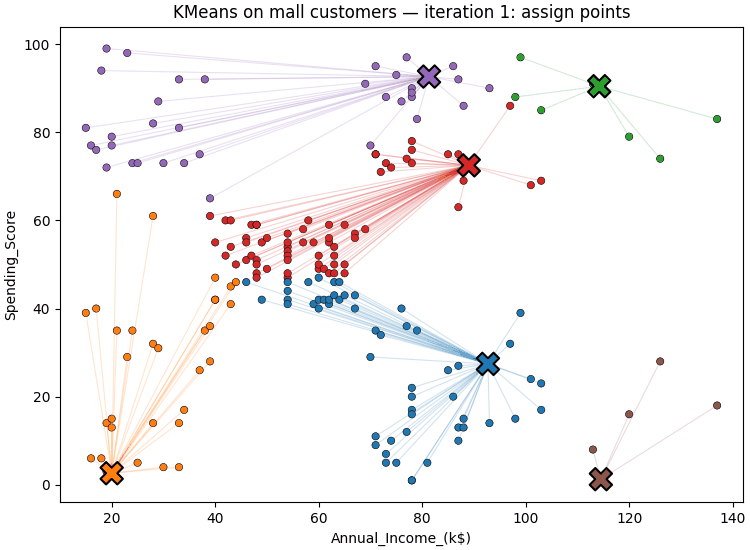

In [ ]:
# Build a step-by-step KMeans animation on the mall customers data.
# We implement Lloyd's algorithm manually so we can snapshot each iteration.
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

K = 6
MAX_ITERS = 14
SEED = 0
FEATURES = ["Annual_Income_(k$)", "Spending_Score", "Age"]
OUTPUT_GIF = "kmeans_animation.gif"

rng = np.random.default_rng(SEED)
data = pd.read_csv("mall_customers.csv")
X = data[FEATURES].to_numpy(dtype=float)
n = X.shape[0]

# Initialise centroids at random points inside the data's bounding box.
centroids = rng.uniform(X.min(axis=0), X.max(axis=0), size=(K, 2))

frames = []          # each frame: (labels, centroids, iteration, phase)
labels = np.zeros(n, dtype=int)

for it in range(MAX_ITERS):
    # 1. Assign step: nearest centroid for each point.
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = dists.argmin(axis=1)
    frames.append((labels.copy(), centroids.copy(), it, "assign points"))

    # 2. Update step: move each centroid to the mean of its assigned points.
    new_centroids = centroids.copy()
    for k in range(K):
        mask = labels == k
        if mask.any():
            new_centroids[k] = X[mask].mean(axis=0)
    frames.append((labels.copy(), new_centroids.copy(), it, "move centroids"))

    # Hold the "move centroids" frame for ~2 extra seconds between iterations
    # so viewers can compare the new centroid positions before the next assign step.
    for _ in range(3):
        frames.append((labels.copy(), new_centroids.copy(), it, "move centroids"))

    if np.allclose(new_centroids, centroids, atol=1e-4):
        # Converged. Hold the final frame for emphasis and stop.
        for _ in range(3):
            frames.append((labels.copy(), new_centroids.copy(), it, "converged"))
        centroids = new_centroids
        break
    centroids = new_centroids

print(f"Captured {len(frames)} frames over {it + 1} iterations.")

# --- Render the frames as a GIF ---
palette = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(7.5, 5.5), layout="constrained")
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

def draw(frame):
    labels, centroids, it, phase = frame
    ax.clear()
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(FEATURES[0])
    ax.set_ylabel(FEATURES[1])

    # Light lines from each point to its current centroid.
    for k in range(K):
        mask = labels == k
        if not mask.any():
            continue
        cx, cy = centroids[k]
        for px, py in X[mask]:
            ax.plot([px, cx], [py, cy], color=palette(k), alpha=0.20, linewidth=0.8)

    # Points coloured by current cluster.
    ax.scatter(X[:, 0], X[:, 1], c=[palette(l) for l in labels],
               s=28, edgecolor="k", linewidth=0.4)

    # Centroids drawn as large X markers.
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c=[palette(k) for k in range(K)], s=260,
               marker="X", edgecolor="black", linewidth=1.5, zorder=5)

    ax.set_title(f"KMeans on mall customers — iteration {it + 1}: {phase}")

anim = FuncAnimation(fig, draw, frames=frames, interval=700)
anim.save(OUTPUT_GIF, writer=PillowWriter(fps=1.6))
plt.close(fig)

Image(filename=OUTPUT_GIF)


### 9.2. The elbow method as `K` grows

This second animation increases `K` from 1 up to 10. For each value of `K` we run KMeans to convergence on the same two features (`Annual_Income_(k$)`, `Spending_Score`) and snap a frame showing:

- **Left panel:** the elbow plot. A new red point is added every time `K` increases, so the WCSS curve grows on screen — you can literally watch the elbow appear.
- **Right panel:** the resulting clusters and centroids at the current `K`.

This is the same idea we plotted statically in **section 5.2**, but the animation makes it easier to see why the WCSS keeps decreasing and where the curve flattens.


Trained KMeans for K = 1..10, captured 33 frames.


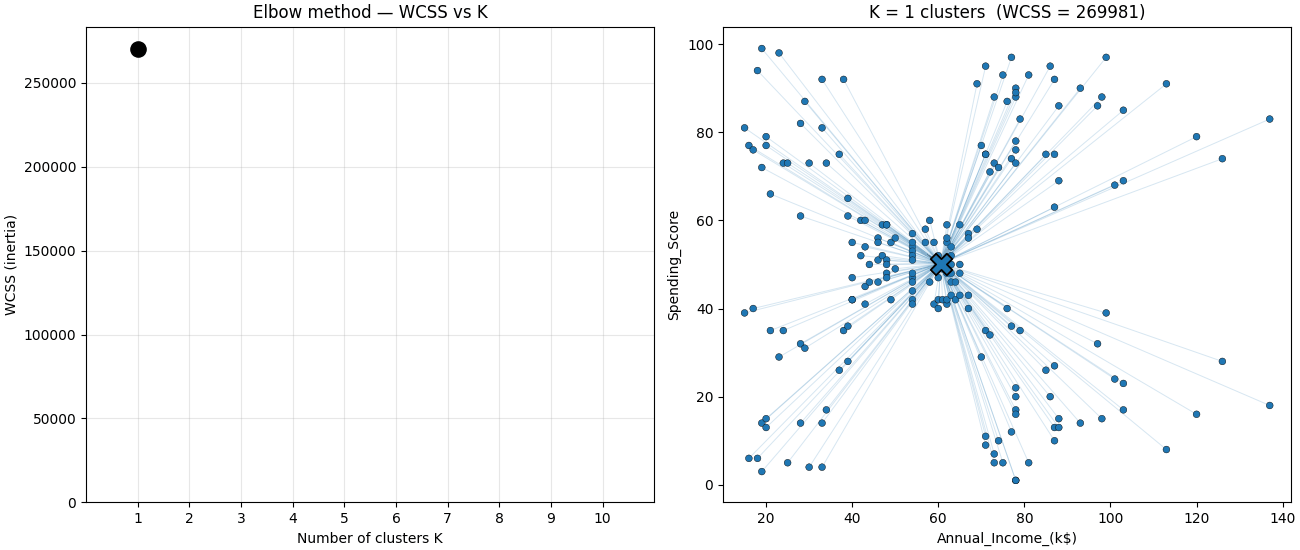

In [ ]:
# Section 9.2: animate the elbow method as K grows from 1 to KMAX.
# For each K we run KMeans to convergence, then build a frame with the
# elbow plot on the left and the resulting clusters on the right.
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

KMAX = 10
MAX_ITERS_PER_K = 12
SEED = 1
FEATURES = ["Annual_Income_(k$)", "Spending_Score", "Age"]
OUTPUT_GIF = "kmeans_elbow_animation.gif"

rng = np.random.default_rng(SEED)
data = pd.read_csv("mall_customers.csv")
X = data[FEATURES].to_numpy(dtype=float)

# Train KMeans manually for each K and store the final state + WCSS.
wcss_per_k = []
labels_per_k = []
centroids_per_k = []

for k in range(1, KMAX + 1):
    centroids = rng.uniform(X.min(axis=0), X.max(axis=0), size=(k, 2))
    for _ in range(MAX_ITERS_PER_K):
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)
        new_centroids = centroids.copy()
        for c in range(k):
            mask = labels == c
            if mask.any():
                new_centroids[c] = X[mask].mean(axis=0)
        if np.allclose(new_centroids, centroids, atol=1e-4):
            centroids = new_centroids
            break
        centroids = new_centroids
    final_dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    wcss_per_k.append(np.sum(np.min(final_dists, axis=1) ** 2))
    labels_per_k.append(labels.copy())
    centroids_per_k.append(centroids.copy())

# 3 frames per K so each step in the animation lingers ~1.9 s at fps=1.6.
frames = [k_idx for k_idx in range(KMAX) for _ in range(3)]
# Hold the final K for a couple of extra seconds at the end.
frames += [KMAX - 1] * 3
print(f"Trained KMeans for K = 1..{KMAX}, captured {len(frames)} frames.")

# --- Render -------------------------------------------------------------
palette = plt.get_cmap("tab10")
fig, (ax_elbow, ax_scatter) = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
wcss_y_max = max(wcss_per_k) * 1.05

def draw(k_idx):
    k = k_idx + 1
    labels = labels_per_k[k_idx]
    centroids = centroids_per_k[k_idx]

    ax_elbow.clear()
    ax_scatter.clear()

    # Left: growing elbow curve
    ax_elbow.set_xlim(0, KMAX + 1)
    ax_elbow.set_ylim(0, wcss_y_max)
    ax_elbow.set_xticks(range(1, KMAX + 1))
    ax_elbow.set_xlabel("Number of clusters K")
    ax_elbow.set_ylabel("WCSS (inertia)")
    ax_elbow.set_title("Elbow method — WCSS vs K")
    ks_so_far = list(range(1, k + 1))
    ax_elbow.plot(ks_so_far, wcss_per_k[:k], "o-", color="red", linewidth=2)
    ax_elbow.scatter([k], [wcss_per_k[k_idx]], color="black", s=120, zorder=5)
    ax_elbow.grid(alpha=0.3)

    # Right: clusters at this K
    ax_scatter.set_xlim(x_min, x_max)
    ax_scatter.set_ylim(y_min, y_max)
    ax_scatter.set_xlabel(FEATURES[0])
    ax_scatter.set_ylabel(FEATURES[1])
    ax_scatter.set_title(f"K = {k} clusters  (WCSS = {wcss_per_k[k_idx]:.0f})")

    for c in range(k):
        mask = labels == c
        if not mask.any():
            continue
        cx, cy = centroids[c]
        for px, py in X[mask]:
            ax_scatter.plot([px, cx], [py, cy], color=palette(c % 10), alpha=0.18, linewidth=0.7)

    ax_scatter.scatter(X[:, 0], X[:, 1], c=[palette(l % 10) for l in labels],
                       s=24, edgecolor="k", linewidth=0.3)
    ax_scatter.scatter(centroids[:, 0], centroids[:, 1],
                       c=[palette(c % 10) for c in range(k)], s=240,
                       marker="X", edgecolor="black", linewidth=1.3, zorder=5)

anim = FuncAnimation(fig, draw, frames=frames, interval=700)
anim.save(OUTPUT_GIF, writer=PillowWriter(fps=1.6))
plt.close(fig)

Image(filename=OUTPUT_GIF)


### 9.3. Three-panel animation: elbow, silhouette score, and 3D clusters

This animation pulls the previous ideas together. As `K` grows from 2 to 10:

- **Left panel** — the **elbow plot** (WCSS) builds up point by point.
- **Middle panel** — the **silhouette score** builds up alongside it (recall: higher is better).
- **Right panel** — a **3D scatter** of the customers using `Annual_Income_(k$)`, `Spending_Score`, and `Age`, recoloured by their cluster assignment, with the centroids drawn as large `X` markers. The view rotates slightly each step so you can see the cluster shapes from different angles.

**Note on consistency with section 5.3:** the model is fit with **scikit-learn `KMeans(random_state=0, n_init=10)` on all 4 features** (`Gender, Age, Annual_Income, Spending_Score`), exactly as in section 5.3. The 3D scatter only draws three of those four features (Gender is the unseen 4th dimension), but the elbow and silhouette curves you see here are the same numbers we computed earlier — for example the silhouette peaks around `K = 6` at ≈ 0.45.


Trained KMeans for K = 2..10, captured 30 frames.


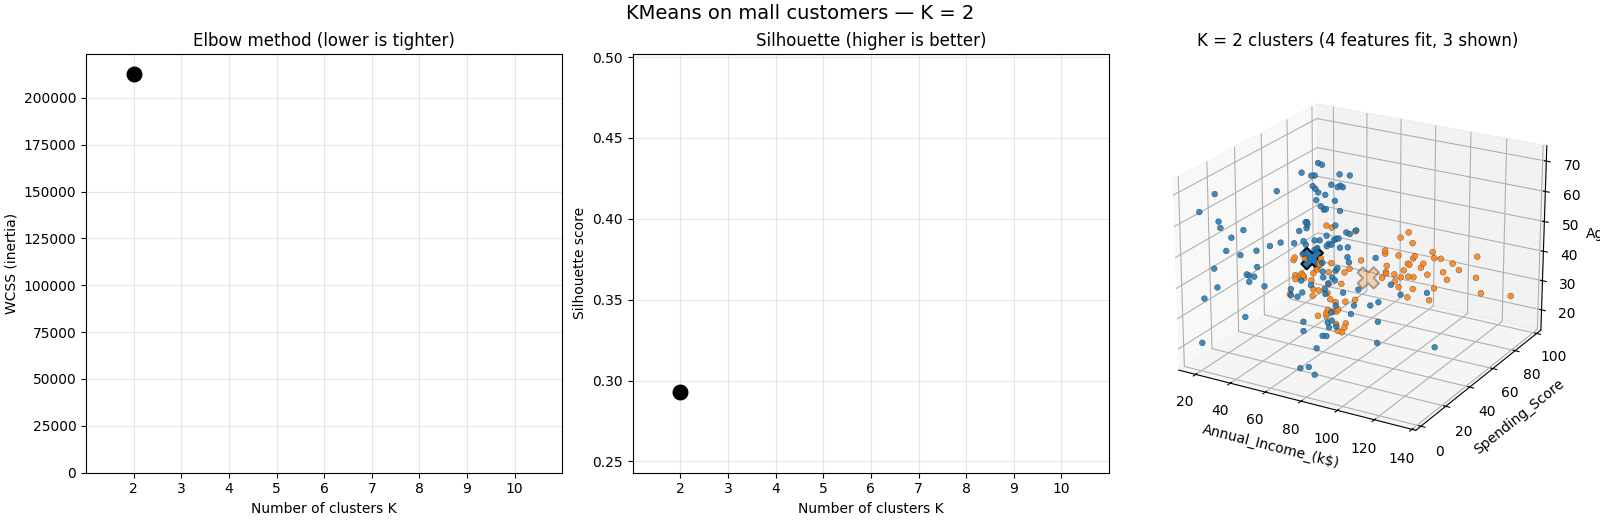

In [ ]:
# Section 9.3: three-panel animation — elbow, silhouette, 3D clusters.
# Fits sklearn KMeans on all 4 features (Gender + Income + Spending + Age),
# matching section 5.3 exactly, so the elbow and silhouette curves here
# show the same numbers students computed earlier (e.g. K=6 silhouette ≈ 0.45).
# The 3D scatter shows three of those four features; Gender is the unseen 4th dim.
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
# KMeans and silhouette_score are already imported at the top of the notebook.

KMIN, KMAX = 2, 10
SEED = 0  # matches section 5.3's random_state=0
FEATURES_3D = ["Annual_Income_(k$)", "Spending_Score", "Age"]
OUTPUT_GIF = "kmeans_3d_animation.gif"

data = pd.read_csv("mall_customers.csv")
gender_int = (data["Genre"] == "Male").astype(int)
X4 = data[FEATURES_3D].assign(Gender=gender_int).to_numpy(dtype=float)  # 4-feature matrix used to fit
X3 = data[FEATURES_3D].to_numpy(dtype=float)                             # 3 features used for the 3D plot

ks = list(range(KMIN, KMAX + 1))
wcss_per_k, sil_per_k, labels_per_k, centroids3_per_k = [], [], [], []

for k in ks:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    model.fit(X4)
    wcss_per_k.append(float(model.inertia_))
    sil_per_k.append(float(silhouette_score(X4, model.labels_)))
    labels_per_k.append(model.labels_.copy())
    centroids3_per_k.append(model.cluster_centers_[:, :3].copy())  # drop Gender dim for plotting

# 3 frames per K + a few hold frames at the end (~2 s holds at fps=1.4).
frames = [k_idx for k_idx in range(len(ks)) for _ in range(3)]
frames += [len(ks) - 1] * 3
print(f"Trained KMeans for K = {KMIN}..{KMAX}, captured {len(frames)} frames.")

# --- Render -------------------------------------------------------------
palette = plt.get_cmap("tab10")
fig = plt.figure(figsize=(16, 5.2), layout="constrained")
ax_elbow = fig.add_subplot(1, 3, 1)
ax_sil = fig.add_subplot(1, 3, 2)
ax_3d = fig.add_subplot(1, 3, 3, projection="3d")

x_lo, x_hi = X3[:, 0].min() - 5, X3[:, 0].max() + 5
y_lo, y_hi = X3[:, 1].min() - 5, X3[:, 1].max() + 5
z_lo, z_hi = X3[:, 2].min() - 5, X3[:, 2].max() + 5
wcss_y_max = max(wcss_per_k) * 1.05
sil_pad = 0.05
sil_y_lo, sil_y_hi = min(sil_per_k) - sil_pad, max(sil_per_k) + sil_pad

def draw(k_idx):
    k = ks[k_idx]
    labels = labels_per_k[k_idx]
    centroids3 = centroids3_per_k[k_idx]
    ks_so_far = ks[: k_idx + 1]

    ax_elbow.clear(); ax_sil.clear(); ax_3d.clear()

    # Left: elbow
    ax_elbow.set_xlim(KMIN - 1, KMAX + 1); ax_elbow.set_ylim(0, wcss_y_max)
    ax_elbow.set_xticks(ks)
    ax_elbow.set_xlabel("Number of clusters K"); ax_elbow.set_ylabel("WCSS (inertia)")
    ax_elbow.set_title("Elbow method (lower is tighter)")
    ax_elbow.plot(ks_so_far, wcss_per_k[: k_idx + 1], "o-", color="red", linewidth=2)
    ax_elbow.scatter([k], [wcss_per_k[k_idx]], color="black", s=110, zorder=5)
    ax_elbow.grid(alpha=0.3)

    # Middle: silhouette
    ax_sil.set_xlim(KMIN - 1, KMAX + 1); ax_sil.set_ylim(sil_y_lo, sil_y_hi)
    ax_sil.set_xticks(ks)
    ax_sil.set_xlabel("Number of clusters K"); ax_sil.set_ylabel("Silhouette score")
    ax_sil.set_title("Silhouette (higher is better)")
    ax_sil.plot(ks_so_far, sil_per_k[: k_idx + 1], "s-", color="tab:blue", linewidth=2)
    ax_sil.scatter([k], [sil_per_k[k_idx]], color="black", s=110, zorder=5)
    ax_sil.grid(alpha=0.3)

    # Right: 3D scatter (4-feature labels, 3 features shown)
    ax_3d.set_xlim(x_lo, x_hi); ax_3d.set_ylim(y_lo, y_hi); ax_3d.set_zlim(z_lo, z_hi)
    ax_3d.set_xlabel(FEATURES_3D[0]); ax_3d.set_ylabel(FEATURES_3D[1]); ax_3d.set_zlabel(FEATURES_3D[2])
    ax_3d.set_title(f"K = {k} clusters (4 features fit, 3 shown)")
    ax_3d.view_init(elev=22, azim=-60 + 4 * k_idx)  # slow rotation across frames
    ax_3d.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
                  c=[palette(l % 10) for l in labels], s=18,
                  edgecolor="k", linewidth=0.2, alpha=0.85)
    ax_3d.scatter(centroids3[:, 0], centroids3[:, 1], centroids3[:, 2],
                  c=[palette(c % 10) for c in range(k)], s=240,
                  marker="X", edgecolor="black", linewidth=1.5)

    fig.suptitle(f"KMeans on mall customers — K = {k}", fontsize=14)

anim = FuncAnimation(fig, draw, frames=frames, interval=900)
anim.save(OUTPUT_GIF, writer=PillowWriter(fps=1.4))
plt.close(fig)

Image(filename=OUTPUT_GIF)
